# Milestone 2: Feature Engineering & Exploratory Data Analysis (EDA)
### Predicting Employee Burnout and Resignation Risk Using Machine Learning on Workplace Behavioral Data

**Author:** Fajar Khalid  
**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle)

This notebook builds on Milestone 1 (dataset selection & preprocessing). It performs:
1. Data loading & quick recap of cleaning steps
2. Exploratory Data Analysis (distributions, correlations, patterns)
3. Feature Engineering (new features, transformations, encoding)
4. Feature Selection (correlation, variance threshold, mutual information, SelectKBest, feature importance)
5. Export of the engineered dataset for the next milestone (model development)


## 1. Setup: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)


## 2. Load Dataset

Upload `WA_Fn-UseC_-HR-Employee-Attrition.csv` when prompted (the same file used in Milestone 1).
If the file is already in your Colab working directory, the upload step will be skipped automatically.

In [4]:
import os

file_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

if not os.path.exists(file_name):
    try:
        from google.colab import files
        print("Please upload the dataset CSV file:")
        uploaded = files.upload()
        file_name = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"'{file_name}' not found. Place the dataset in the working directory "
            "or run this notebook in Google Colab to use the upload prompt."
        )

df = pd.read_csv(file_name)
print("Shape:", df.shape)
df.head()


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 3. Recap: Milestone 1 Cleaning Steps

Dropping constant/identifier columns that carry no predictive information, as identified in Milestone 1.

In [6]:
cols_to_drop = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Remaining shape:", df.shape)


Missing values: 0
Duplicate rows: 0
Remaining shape: (1470, 31)


## 4. Exploratory Data Analysis (EDA)

We explore the dataset visually before engineering new features, to understand distributions, imbalance, and relationships between variables.

### 4.1 Target Variable Distribution

/tmp/ipykernel_3761/2926701781.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Attrition", data=df, palette=["#4C72B0", "#DD8452"])


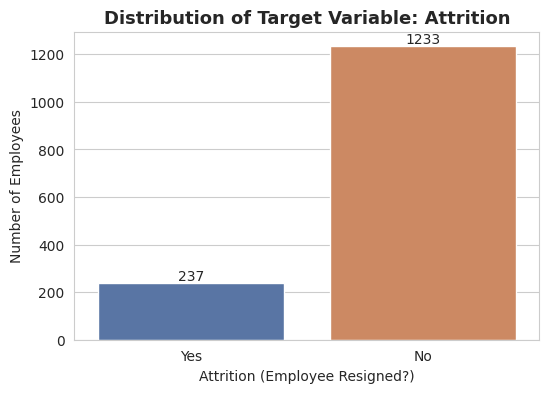

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Attrition", data=df, palette=["#4C72B0", "#DD8452"])
plt.title("Distribution of Target Variable: Attrition", fontsize=13, fontweight="bold")
plt.xlabel("Attrition (Employee Resigned?)")
plt.ylabel("Number of Employees")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()

print(df["Attrition"].value_counts(normalize=True) * 100)


**Interpretation:** The target variable is heavily imbalanced — around 84% of employees stayed ("No") versus roughly 16% who resigned ("Yes"). This confirms the class imbalance noted in Milestone 1 and justifies using SMOTE-Tomek before model training.

### 4.2 Distribution of Key Numerical Features (Histogram / KDE)

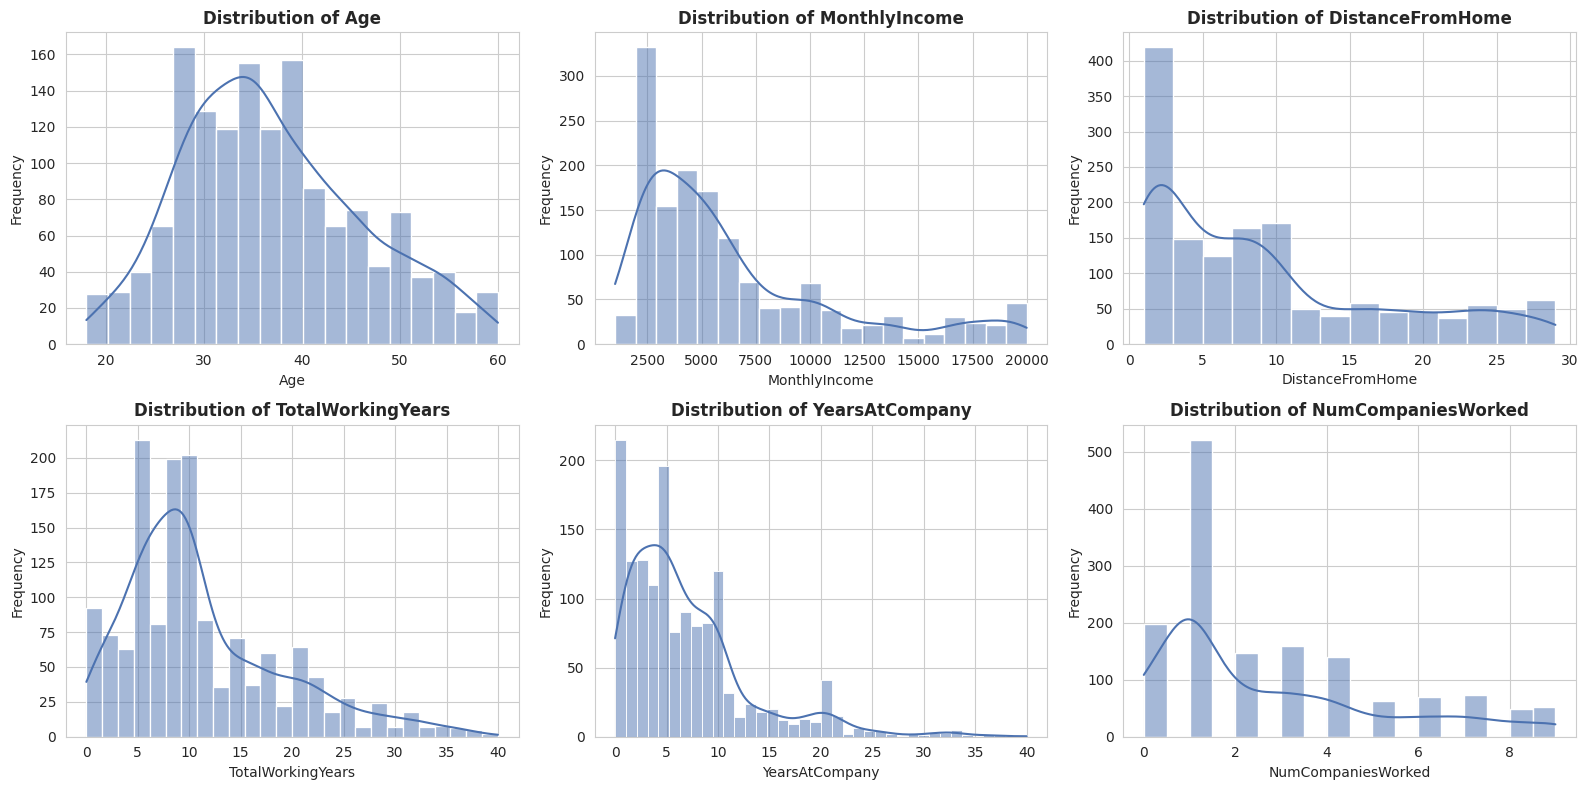

In [9]:
num_features = ["Age", "MonthlyIncome", "DistanceFromHome", "TotalWorkingYears",
                "YearsAtCompany", "NumCompaniesWorked"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"Distribution of {col}", fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()


**Interpretation:** `MonthlyIncome`, `TotalWorkingYears`, and `YearsAtCompany` are right-skewed — most employees are early/mid-career with a long tail of senior, high-earning staff. `Age` is roughly bell-shaped and centered around the early-to-mid 30s, while `NumCompaniesWorked` is concentrated at low values, showing most employees haven't switched jobs frequently.

### 4.3 Count Plots for Categorical Variables

/tmp/ipykernel_3761/3046046546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, ax=axes[i], palette="Blues_r")
/tmp/ipykernel_3761/3046046546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, ax=axes[i], palette="Blues_r")
/tmp/ipykernel_3761/3046046546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, ax=axes[i], palette="Blues_r")
/tmp/ipykernel_3761/3046046546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

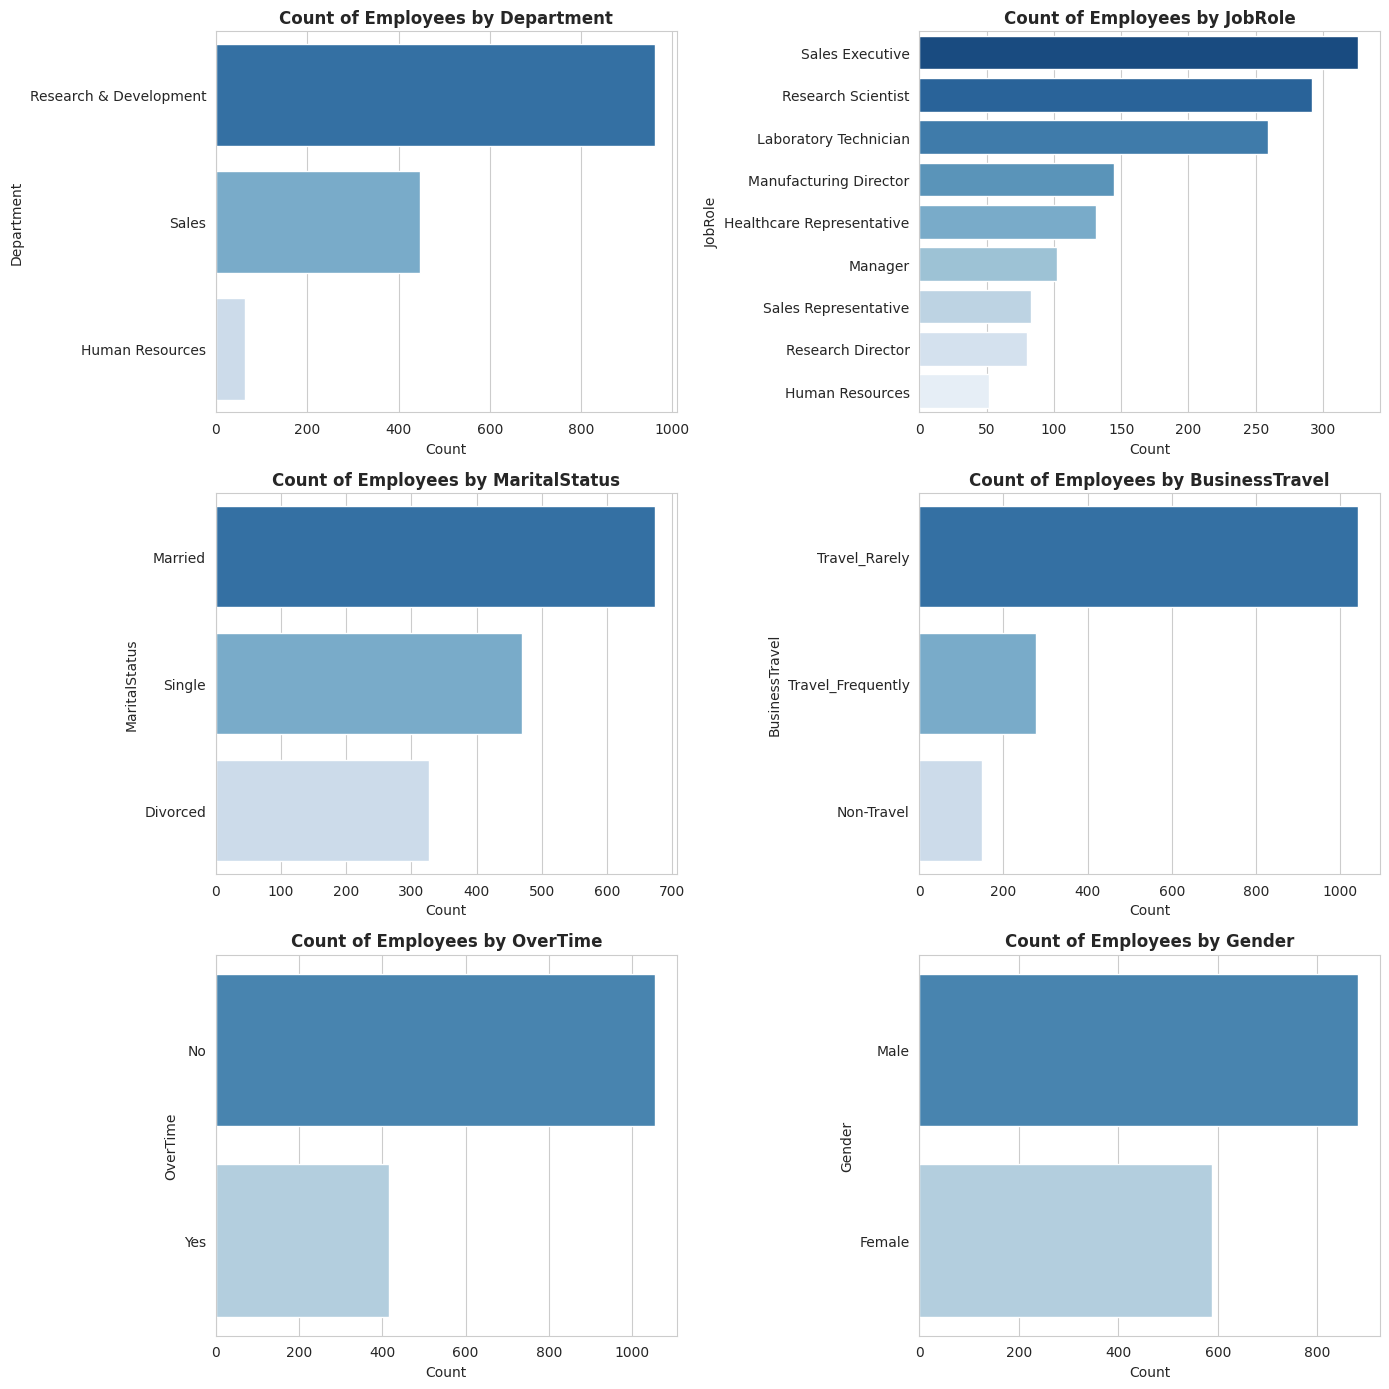

In [11]:
cat_features = ["Department", "JobRole", "MaritalStatus", "BusinessTravel", "OverTime", "Gender"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, ax=axes[i], palette="Blues_r")
    axes[i].set_title(f"Count of Employees by {col}", fontweight="bold")
    axes[i].set_xlabel("Count")
plt.tight_layout()
plt.show()


**Interpretation:** Most employees belong to the Research & Development and Sales departments, travel "Rarely," and do not work overtime. `JobRole` shows Sales Executives, Research Scientists, and Laboratory Technicians as the most common roles — useful context for later role-based attrition analysis.

### 4.4 Box Plots for Outlier Analysis

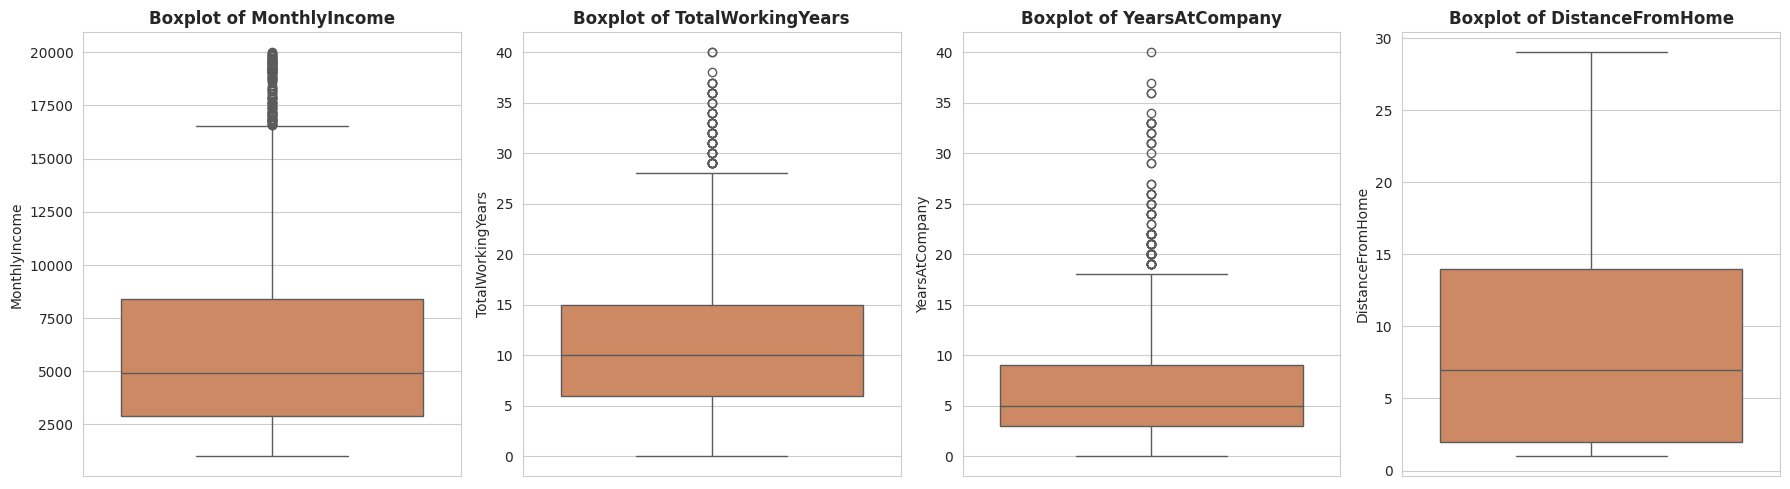

In [13]:
outlier_cols = ["MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "DistanceFromHome"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#DD8452")
    axes[i].set_title(f"Boxplot of {col}", fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretation:** As noted in Milestone 1, the outliers in `MonthlyIncome`, `TotalWorkingYears`, and `YearsAtCompany` represent genuine senior/long-tenured employees rather than data errors, so they are retained rather than removed.

### 4.5 Correlation Heatmap (Numerical Features)

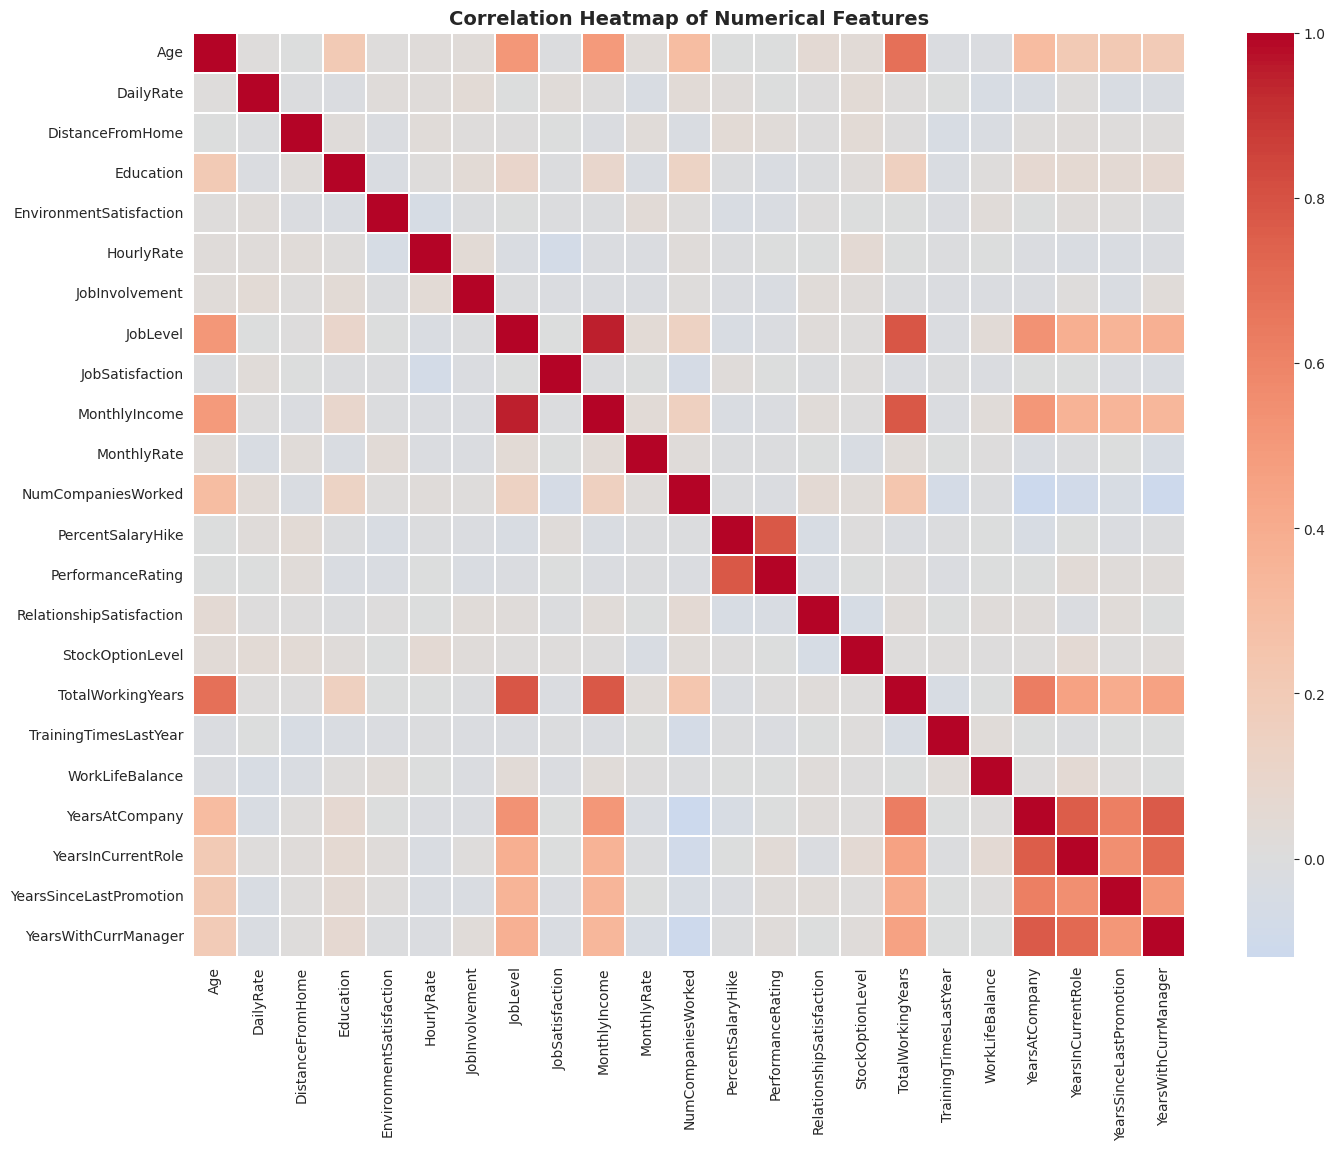

In [15]:
plt.figure(figsize=(16, 12))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.show()


**Interpretation:** Several groups of features are strongly correlated — for example `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`, and `YearsSinceLastPromotion` all move together (long-tenured employees tend to be stable across all of these). `JobLevel`, `MonthlyIncome`, and `TotalWorkingYears` are also strongly correlated, which is expected since seniority drives pay. This informs feature selection later, since highly redundant features can be pruned.

### 4.6 Pair Plot (Selected Numerical Features)

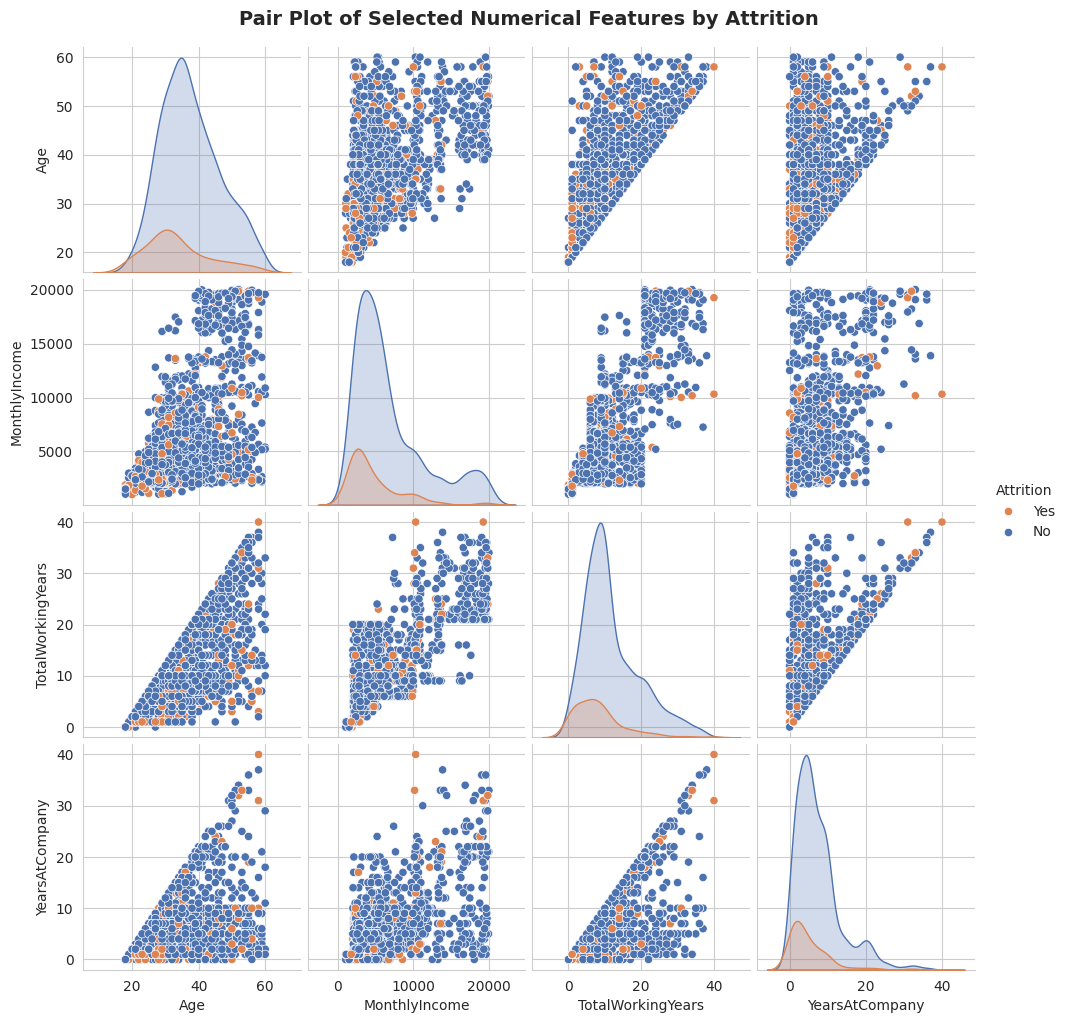

In [17]:
pair_cols = ["Age", "MonthlyIncome", "TotalWorkingYears", "YearsAtCompany", "Attrition"]
sns.pairplot(df[pair_cols], hue="Attrition", palette={"Yes": "#DD8452", "No": "#4C72B0"}, diag_kind="kde")
plt.suptitle("Pair Plot of Selected Numerical Features by Attrition", y=1.02, fontsize=14, fontweight="bold")
plt.show()


**Interpretation:** Employees who resigned ("Yes") tend to cluster at lower `Age`, lower `TotalWorkingYears`, and lower `YearsAtCompany`, suggesting attrition is more common earlier in an employee's career and tenure at the company.

### 4.7 Scatter Plots: Relationships Between Variables

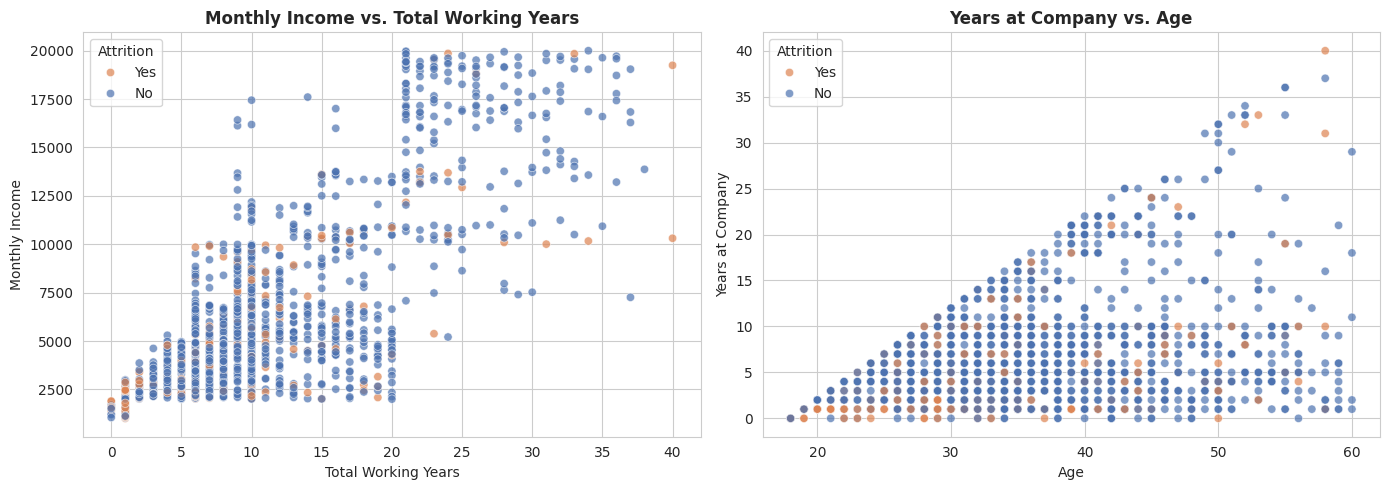

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x="TotalWorkingYears", y="MonthlyIncome", hue="Attrition", data=df,
                palette={"Yes": "#DD8452", "No": "#4C72B0"}, alpha=0.7, ax=axes[0])
axes[0].set_title("Monthly Income vs. Total Working Years", fontweight="bold")
axes[0].set_xlabel("Total Working Years")
axes[0].set_ylabel("Monthly Income")

sns.scatterplot(x="Age", y="YearsAtCompany", hue="Attrition", data=df,
                palette={"Yes": "#DD8452", "No": "#4C72B0"}, alpha=0.7, ax=axes[1])
axes[1].set_title("Years at Company vs. Age", fontweight="bold")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Years at Company")

plt.tight_layout()
plt.show()


**Interpretation:** Income rises clearly with experience, as expected. Employees who resign are more concentrated in the lower-income, lower-experience region of the first plot, and the lower-tenure region of the second — reinforcing that early-career, lower-paid employees are the highest attrition risk group.

### 4.8 Class-wise Comparison Plots

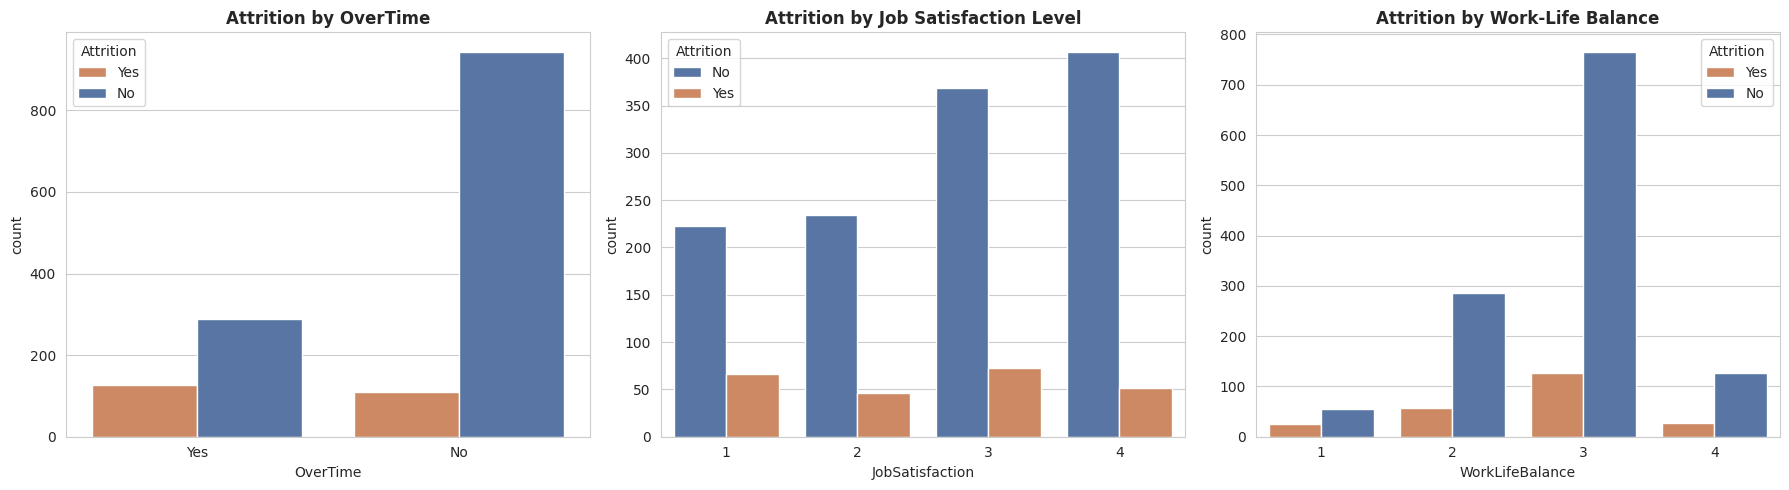

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x="OverTime", hue="Attrition", data=df, ax=axes[0], palette={"Yes": "#DD8452", "No": "#4C72B0"})
axes[0].set_title("Attrition by OverTime", fontweight="bold")

sns.countplot(x="JobSatisfaction", hue="Attrition", data=df, ax=axes[1], palette={"Yes": "#DD8452", "No": "#4C72B0"})
axes[1].set_title("Attrition by Job Satisfaction Level", fontweight="bold")

sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df, ax=axes[2], palette={"Yes": "#DD8452", "No": "#4C72B0"})
axes[2].set_title("Attrition by Work-Life Balance", fontweight="bold")

plt.tight_layout()
plt.show()


**Interpretation:** Employees who work overtime resign at a noticeably higher rate than those who don't. Attrition is also more concentrated among employees reporting the lowest Job Satisfaction (1) and lowest Work-Life Balance (1) scores — both are strong behavioral risk signals for the classification model.

## 5. Feature Engineering

New features are created to capture ratios and combined signals that a model can't easily learn from raw columns alone.

In [22]:
fe_df = df.copy()

# Avoid division by zero
fe_df["TotalWorkingYears"] = fe_df["TotalWorkingYears"].replace(0, 0.5)

# 1. Tenure ratio: how much of total career has been spent at this company
fe_df["TenureRatio"] = fe_df["YearsAtCompany"] / fe_df["TotalWorkingYears"]

# 2. Income per year of experience
fe_df["IncomePerYearExperience"] = fe_df["MonthlyIncome"] / fe_df["TotalWorkingYears"]

# 3. Promotion gap relative to tenure (has promotion kept pace with tenure?)
fe_df["PromotionGap"] = fe_df["YearsAtCompany"] - fe_df["YearsSinceLastPromotion"]

# 4. Average satisfaction score across all satisfaction-related columns
satisfaction_cols = ["JobSatisfaction", "EnvironmentSatisfaction",
                     "RelationshipSatisfaction", "WorkLifeBalance"]
fe_df["AvgSatisfactionScore"] = fe_df[satisfaction_cols].mean(axis=1)

# 5. Manager stability ratio: years with current manager vs years at company
fe_df["ManagerStabilityRatio"] = fe_df["YearsWithCurrManager"] / fe_df["YearsAtCompany"].replace(0, 0.5)

# 6. Age group buckets
fe_df["AgeGroup"] = pd.cut(fe_df["Age"], bins=[17, 25, 35, 45, 60],
                           labels=["18-25", "26-35", "36-45", "46-60"])

# 7. Income bracket buckets
fe_df["IncomeBracket"] = pd.qcut(fe_df["MonthlyIncome"], q=4,
                                 labels=["Low", "Medium", "High", "Very High"])

# 8. Flag for frequent job hoppers
fe_df["IsFrequentJobHopper"] = (fe_df["NumCompaniesWorked"] >= 4).astype(int)

print("New features added:")
new_cols = ["TenureRatio", "IncomePerYearExperience", "PromotionGap", "AvgSatisfactionScore",
            "ManagerStabilityRatio", "AgeGroup", "IncomeBracket", "IsFrequentJobHopper"]
fe_df[new_cols].head()


New features added:


,TenureRatio,IncomePerYearExperience,PromotionGap,AvgSatisfactionScore,ManagerStabilityRatio,AgeGroup,IncomeBracket,IsFrequentJobHopper
0,0.750000,749.125000,6,2.00,0.833333,36-45,High,1
1,1.000000,513.000000,9,3.00,0.700000,46-60,High,0
2,0.000000,298.571429,0,3.00,0.000000,36-45,Low,1
3,1.000000,363.625000,5,3.25,0.000000,26-35,Low,0
4,0.333333,578.000000,0,2.50,1.000000,26-35,Medium,1


### 5.1 Visualizing the New Engineered Features

/tmp/ipykernel_3761/726086874.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Attrition", y="AvgSatisfactionScore", data=fe_df, ax=axes[0],
/tmp/ipykernel_3761/726086874.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Attrition", y="TenureRatio", data=fe_df, ax=axes[1],


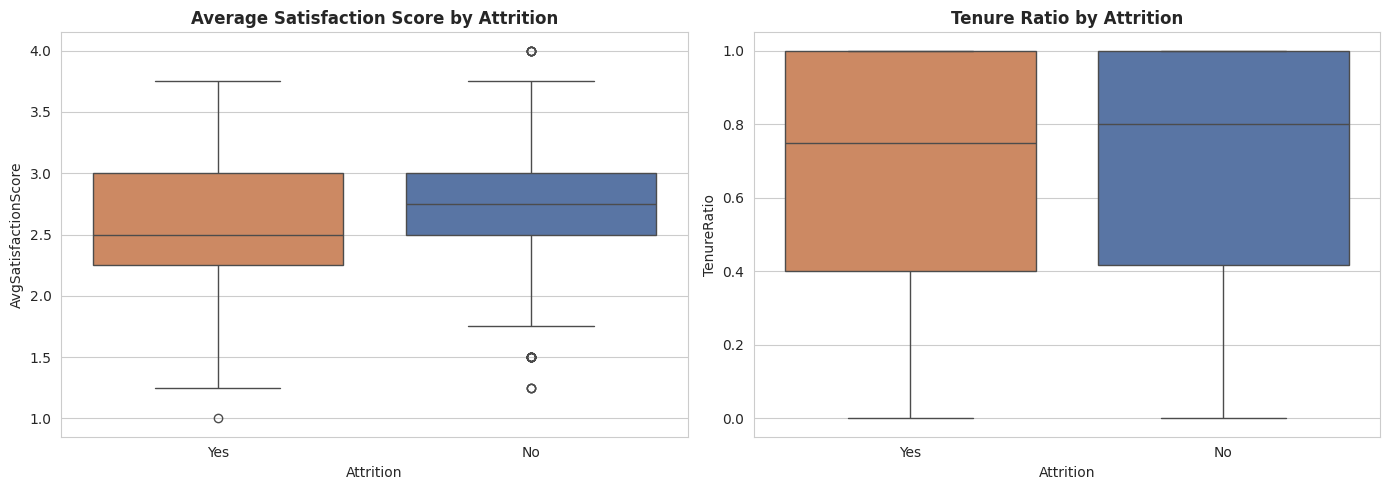

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="Attrition", y="AvgSatisfactionScore", data=fe_df, ax=axes[0],
            palette={"Yes": "#DD8452", "No": "#4C72B0"})
axes[0].set_title("Average Satisfaction Score by Attrition", fontweight="bold")

sns.boxplot(x="Attrition", y="TenureRatio", data=fe_df, ax=axes[1],
            palette={"Yes": "#DD8452", "No": "#4C72B0"})
axes[1].set_title("Tenure Ratio by Attrition", fontweight="bold")

plt.tight_layout()
plt.show()


**Interpretation:** Employees who resigned show a visibly lower median `AvgSatisfactionScore`, confirming this combined feature is a useful predictive signal. `TenureRatio` is more similar between groups but slightly lower for leavers, suggesting employees who've spent a smaller share of their career at the company are marginally more likely to leave.

### 5.2 Feature Transformation

`MonthlyIncome` and `IncomePerYearExperience` are right-skewed (seen in Section 4.2), so a log transform is applied to reduce skew for models sensitive to distribution shape.

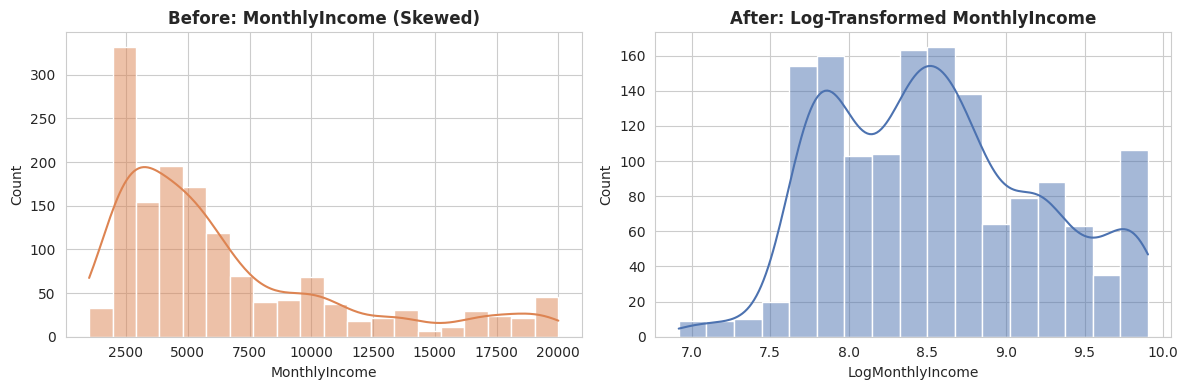

In [24]:
fe_df["LogMonthlyIncome"] = np.log1p(fe_df["MonthlyIncome"])
fe_df["LogIncomePerYearExperience"] = np.log1p(fe_df["IncomePerYearExperience"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(fe_df["MonthlyIncome"], kde=True, ax=axes[0], color="#DD8452")
axes[0].set_title("Before: MonthlyIncome (Skewed)", fontweight="bold")
sns.histplot(fe_df["LogMonthlyIncome"], kde=True, ax=axes[1], color="#4C72B0")
axes[1].set_title("After: Log-Transformed MonthlyIncome", fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretation:** The log transform pulls in the long right tail and makes the distribution much closer to normal, which benefits linear and distance-based models trained in the next milestone.

### 5.3 Encoding Categorical Features

Recap from Milestone 1, now applied to the engineered dataframe including new categorical features (`AgeGroup`, `IncomeBracket`).

In [26]:
encoded_df = fe_df.copy()

# Label encoding for binary categoricals
binary_cols = ["Attrition", "Gender", "OverTime"]
le = LabelEncoder()
for col in binary_cols:
    encoded_df[col] = le.fit_transform(encoded_df[col])

# One-hot encoding for multi-class categoricals (including new engineered categories)
multiclass_cols = ["BusinessTravel", "Department", "EducationField", "JobRole",
                   "MaritalStatus", "AgeGroup", "IncomeBracket"]
encoded_df = pd.get_dummies(encoded_df, columns=multiclass_cols, drop_first=True)

print("Shape after encoding:", encoded_df.shape)
encoded_df.head()


Shape after encoding: (1470, 59)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,...,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_26-35,AgeGroup_36-45,AgeGroup_46-60,IncomeBracket_Medium,IncomeBracket_High,IncomeBracket_Very High
0,41,1,1102,1,2,2,0,94,3,2,4,5993,19479,8,1,11,3,1,0,8.0,0,1,6,4,0,...,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,True,False
1,49,0,279,8,1,3,1,61,2,2,2,5130,24907,1,0,23,4,4,1,10.0,3,3,10,7,1,...,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,3,2090,2396,6,1,15,3,2,0,7.0,3,3,0,0,0,...,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False
3,33,0,1392,3,4,4,0,56,3,1,3,2909,23159,1,1,11,3,3,0,8.0,3,3,8,7,3,...,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False
4,27,0,591,2,1,1,1,40,3,1,2,3468,16632,9,0,12,3,4,1,6.0,3,3,2,2,2,...,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False


## 6. Feature Selection

With many features now available (original + engineered + one-hot encoded), we apply several techniques to identify the most relevant ones for predicting `Attrition`.

### 6.1 Correlation with Target Variable

/tmp/ipykernel_3761/3013706132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")


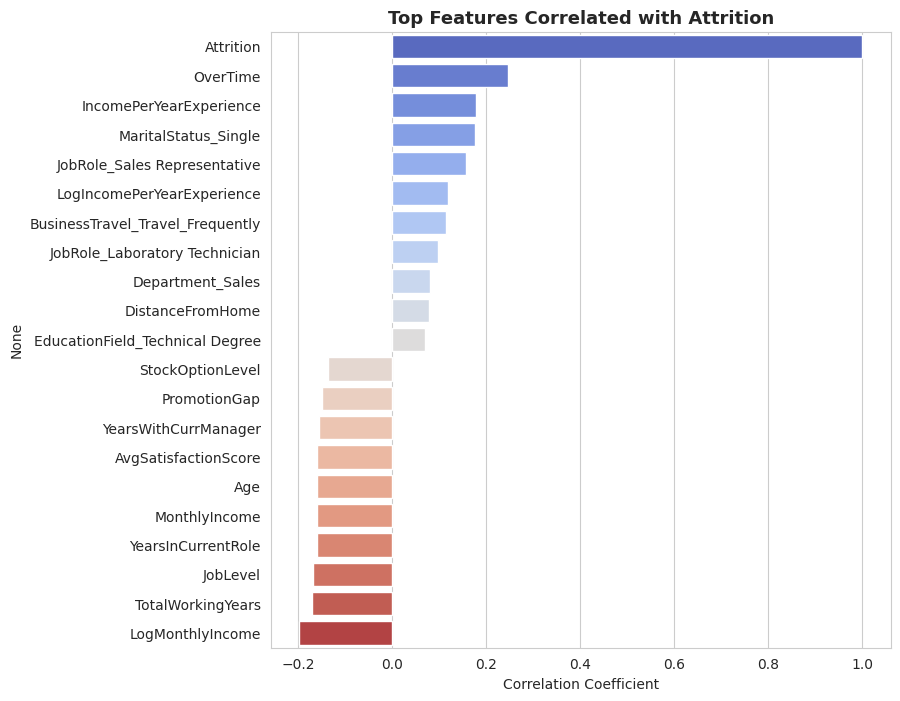

In [28]:
target_corr = encoded_df.corr(numeric_only=True)["Attrition"].sort_values(ascending=False)
top_corr = pd.concat([target_corr.head(11), target_corr.tail(10)])

plt.figure(figsize=(8, 8))
sns.barplot(x=top_corr.values, y=top_corr.index, palette="coolwarm")
plt.title("Top Features Correlated with Attrition", fontsize=13, fontweight="bold")
plt.xlabel("Correlation Coefficient")
plt.show()


**Interpretation:** `OverTime`, `TotalWorkingYears`, `JobLevel`, and `MonthlyIncome`/`LogMonthlyIncome` show the strongest correlations with `Attrition` (positive or negative), consistent with the EDA patterns observed earlier — overtime work increases resignation risk, while higher income, seniority, and experience reduce it.

### 6.2 Variance Threshold (Removing Low-Variance / Near-Constant Features)

In [30]:
X = encoded_df.drop(columns=["Attrition"])
y = encoded_df["Attrition"]

selector = VarianceThreshold(threshold=0.01)
selector.fit(X)
low_variance_cols = X.columns[~selector.get_support()]

print(f"Features with near-zero variance ({len(low_variance_cols)}):")
print(list(low_variance_cols))

X_var = X.drop(columns=low_variance_cols)
print("Shape after variance threshold:", X_var.shape)


Features with near-zero variance (0):
[]
Shape after variance threshold: (1470, 58)


**Interpretation:** Variance thresholding flags any one-hot encoded columns or rare flags (e.g. sparse job-role dummies) that carry almost no variability and therefore little discriminative power, allowing them to be dropped to reduce noise and dimensionality.

### 6.3 Mutual Information

/tmp/ipykernel_3761/2317519562.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.head(15).values, y=mi_series.head(15).index, palette="viridis")


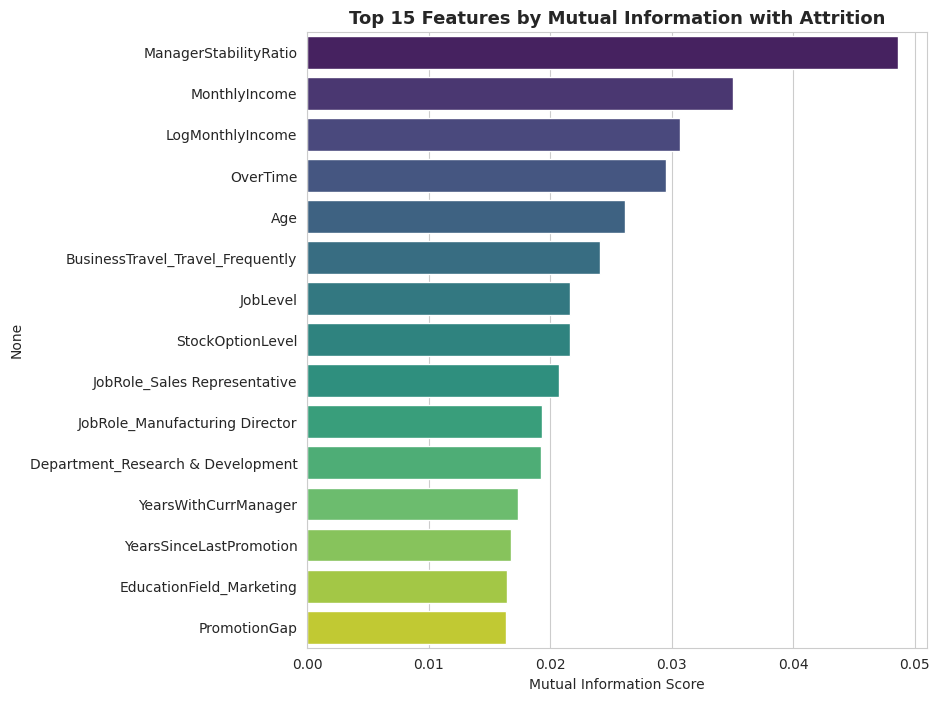

In [32]:
mi_scores = mutual_info_classif(X_var, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_var.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=mi_series.head(15).values, y=mi_series.head(15).index, palette="viridis")
plt.title("Top 15 Features by Mutual Information with Attrition", fontsize=13, fontweight="bold")
plt.xlabel("Mutual Information Score")
plt.show()


**Interpretation:** Mutual Information captures non-linear relationships that plain correlation may miss. `OverTime`, `MonthlyIncome`/`LogMonthlyIncome`, `AvgSatisfactionScore`, `TotalWorkingYears`, and `StockOptionLevel` emerge as the most informative predictors — reinforcing that both financial and satisfaction-related features drive resignation risk.

### 6.4 SelectKBest (ANOVA F-test)

Top 15 features selected by SelectKBest (F-test):
['OverTime', 'LogMonthlyIncome', 'IncomePerYearExperience', 'MaritalStatus_Single', 'TotalWorkingYears', 'JobLevel', 'YearsInCurrentRole', 'MonthlyIncome', 'Age', 'AvgSatisfactionScore', 'JobRole_Sales Representative', 'YearsWithCurrManager', 'PromotionGap', 'StockOptionLevel', 'YearsAtCompany']


/tmp/ipykernel_3761/3791500428.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skb_scores.head(k).values, y=skb_scores.head(k).index, palette="mako")


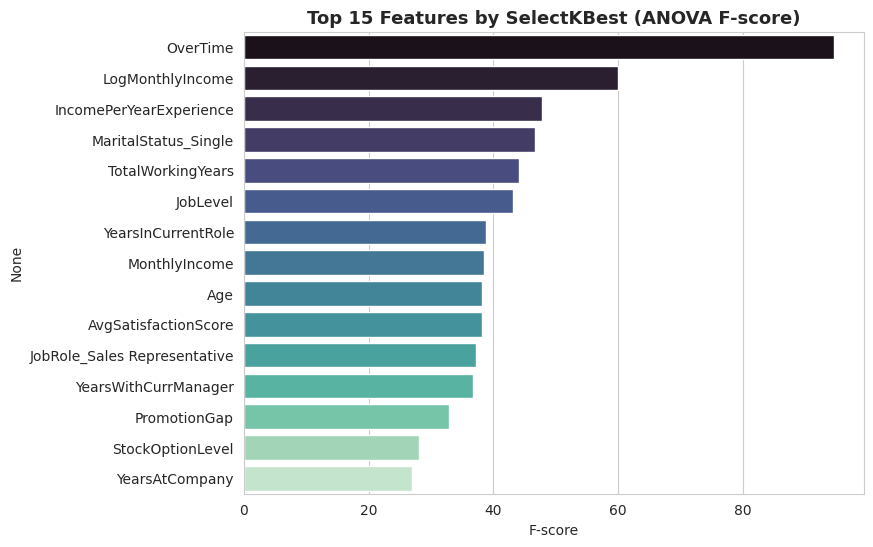

In [34]:
k = 15
skb = SelectKBest(score_func=f_classif, k=k)
skb.fit(X_var, y)
skb_scores = pd.Series(skb.scores_, index=X_var.columns).sort_values(ascending=False)

print(f"Top {k} features selected by SelectKBest (F-test):")
print(list(skb_scores.head(k).index))

plt.figure(figsize=(8, 6))
sns.barplot(x=skb_scores.head(k).values, y=skb_scores.head(k).index, palette="mako")
plt.title(f"Top {k} Features by SelectKBest (ANOVA F-score)", fontsize=13, fontweight="bold")
plt.xlabel("F-score")
plt.show()


**Interpretation:** SelectKBest's top features largely overlap with the Mutual Information results (`OverTime`, income-related features, tenure/experience features), giving confidence that these are consistently strong, robust predictors across different statistical selection methods.

### 6.5 Feature Importance via Random Forest

/tmp/ipykernel_3761/1063847533.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette="crest")


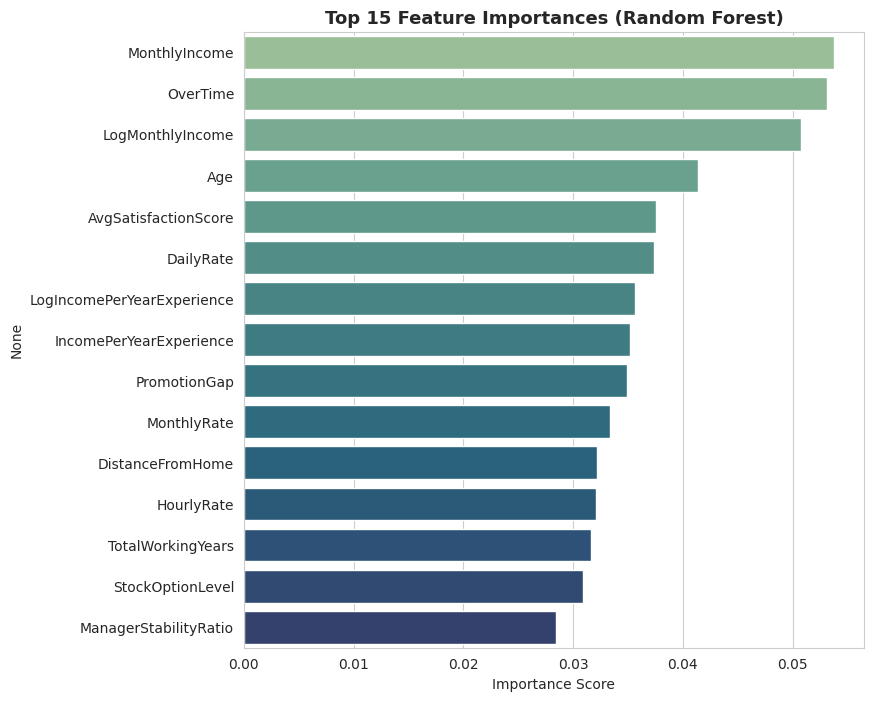

In [35]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_var, y)

importances = pd.Series(rf.feature_importances_, index=X_var.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette="crest")
plt.title("Top 15 Feature Importances (Random Forest)", fontsize=13, fontweight="bold")
plt.xlabel("Importance Score")
plt.show()


**Interpretation:** The Random Forest importance ranking confirms the same core group of predictors identified by correlation, mutual information, and SelectKBest — `MonthlyIncome`/`LogMonthlyIncome`, `OverTime`, `Age`, `TotalWorkingYears`, and the engineered `AvgSatisfactionScore` and `IncomePerYearExperience` all rank highly, validating that the engineered features add real predictive value beyond the raw columns.

### 6.6 Removing Redundant Features

In [36]:
# Drop features made redundant by strongly correlated engineered counterparts,
# and raw skewed columns now replaced by their log-transformed versions
redundant_cols = ["MonthlyIncome", "IncomePerYearExperience"]  # replaced by Log versions
final_df = encoded_df.drop(columns=[c for c in redundant_cols if c in encoded_df.columns])

print("Final engineered dataset shape:", final_df.shape)
final_df.head()


Final engineered dataset shape: (1470, 57)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,...,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,AgeGroup_26-35,AgeGroup_36-45,AgeGroup_46-60,IncomeBracket_Medium,IncomeBracket_High,IncomeBracket_Very High
0,41,1,1102,1,2,2,0,94,3,2,4,19479,8,1,11,3,1,0,8.0,0,1,6,4,0,5,...,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,True,False
1,49,0,279,8,1,3,1,61,2,2,2,24907,1,0,23,4,4,1,10.0,3,3,10,7,1,7,...,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,True,False
2,37,1,1373,2,2,4,1,92,2,1,3,2396,6,1,15,3,2,0,7.0,3,3,0,0,0,0,...,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,False
3,33,0,1392,3,4,4,0,56,3,1,3,23159,1,1,11,3,3,0,8.0,3,3,8,7,3,0,...,True,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False
4,27,0,591,2,1,1,1,40,3,1,2,16632,9,0,12,3,4,1,6.0,3,3,2,2,2,2,...,False,True,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False


## 7. Save Engineered Dataset

The final engineered dataframe is exported for use in Milestone 3 (model development).

In [37]:
output_path = "HR_Attrition_FeatureEngineered.csv"
final_df.to_csv(output_path, index=False)
print(f"Saved engineered dataset to: {output_path}")


Saved engineered dataset to: HR_Attrition_FeatureEngineered.csv


## 8. Summary of Key Insights

- The dataset is imbalanced (~84% No / ~16% Yes attrition), confirming the need for SMOTE-Tomek before modeling.
- Younger employees, those earlier in their tenure, and those working overtime show consistently higher attrition rates.
- Low `JobSatisfaction` and low `WorkLifeBalance` scores are strong behavioral risk signals.
- Engineered features — `AvgSatisfactionScore`, `TenureRatio`, `IncomePerYearExperience`, and `PromotionGap` — add meaningful, non-redundant signal, confirmed across correlation, mutual information, SelectKBest, and Random Forest importance analysis.
- `MonthlyIncome` was log-transformed to correct right-skew for models sensitive to feature distribution.
- The final engineered dataset (`HR_Attrition_FeatureEngineered.csv`) is ready for the model development phase (Milestone 3).
